--- Метрики для модели: Линейная регрессия ---
MAE:  7357.26
MSE:  78476650.10
RMSE: 8858.70
MAPE: 5.95%
-----------------------------------
--- Метрики для модели: Экспоненциальное сглаживание ---
MAE:  6435.73
MSE:  62942727.99
RMSE: 7933.65
MAPE: 5.24%
-----------------------------------


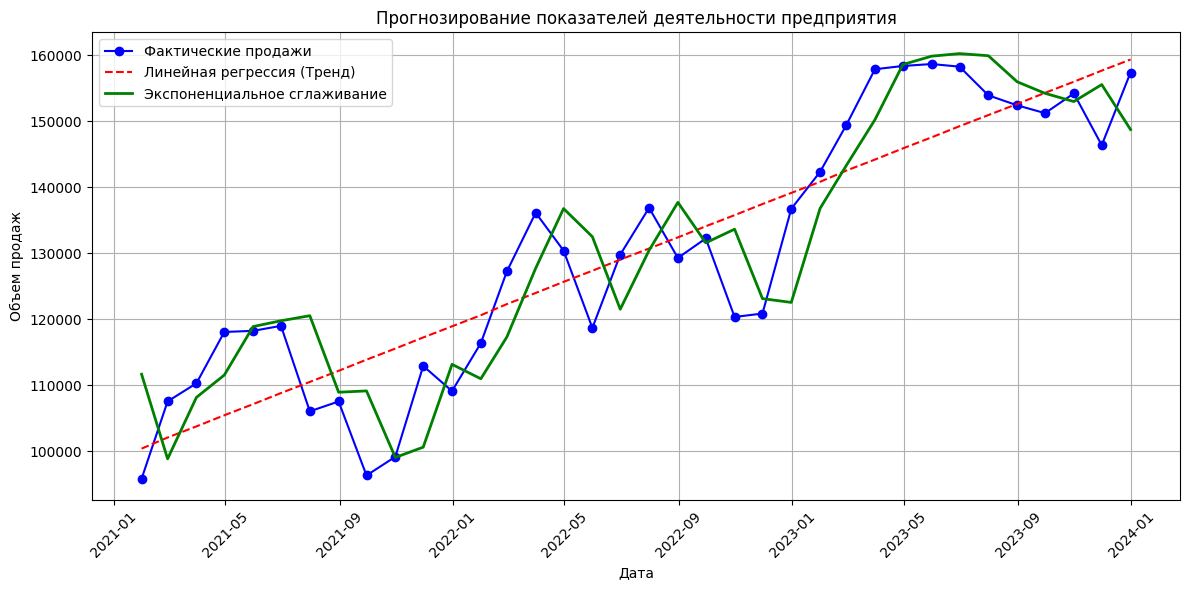

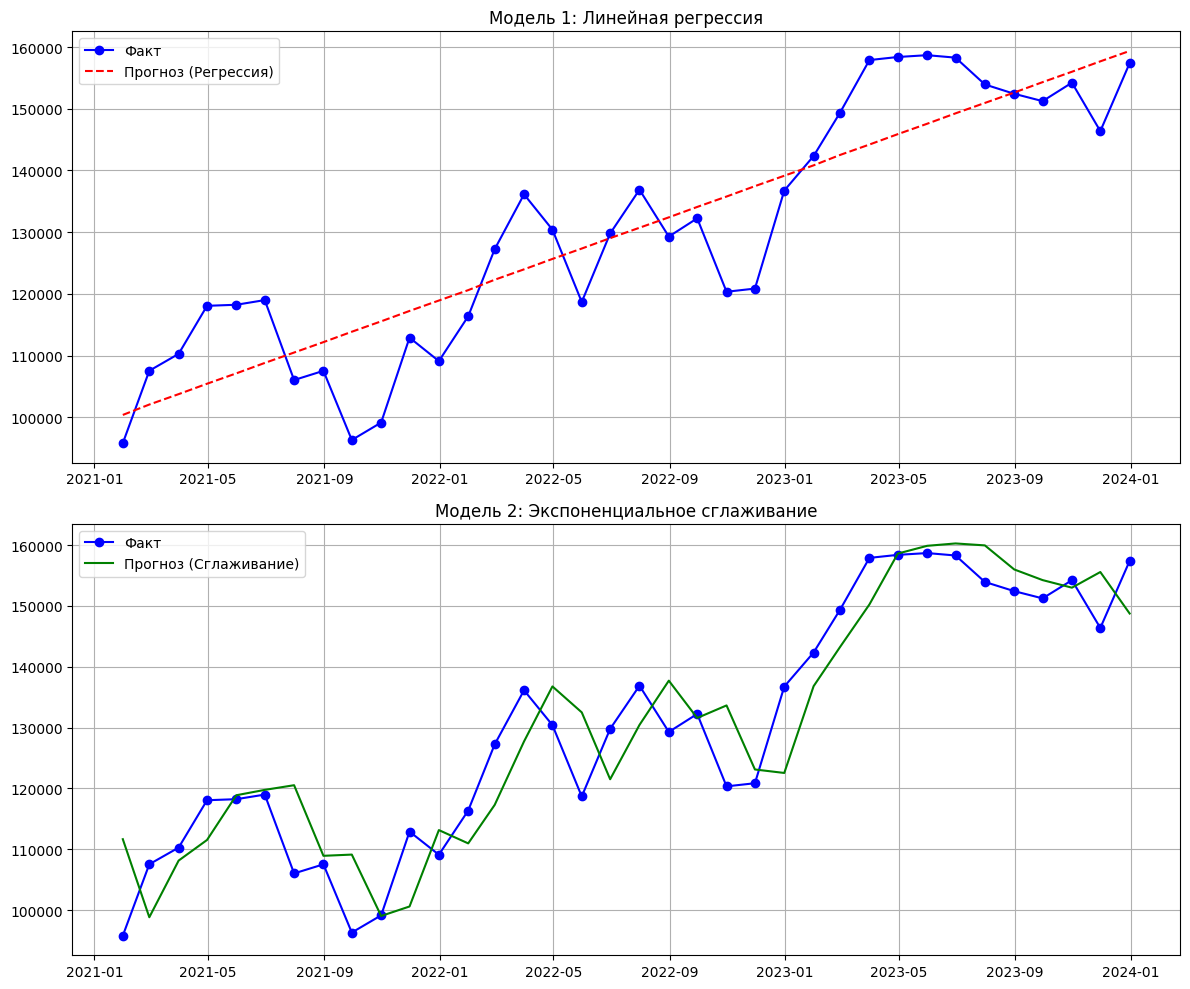

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Данные (уже внутри кода для удобства)
data = {
    'date': pd.to_datetime(['2021-01-31', '2021-02-28', '2021-03-31', '2021-04-30', '2021-05-31', '2021-06-30', '2021-07-31', '2021-08-31', '2021-09-30', '2021-10-31', '2021-11-30', '2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30', '2022-05-31', '2022-06-30', '2022-07-31', '2022-08-31', '2022-09-30', '2022-10-31', '2022-11-30', '2022-12-31', '2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31', '2023-06-30', '2023-07-31', '2023-08-31', '2023-09-30', '2023-10-31', '2023-11-30', '2023-12-31']),
    'monthly_sales': [95799.45, 107537.77, 110276.15, 118061.86, 118234.89, 118989.48, 106032.93, 107523.68, 96311.3, 99141.87, 112903.11, 109103.72, 116366.88, 127244.32, 136134.06, 130410.15, 118684.78, 129791.74, 136885.28, 129287.1, 132244.83, 120340.92, 120857.05, 136741.31, 142342.97, 149384.91, 157896.67, 158394.14, 158688.34, 158289.32, 153940.65, 152430.09, 151239.49, 154229.87, 146379.5, 157402.81]
}
df = pd.DataFrame(data)
df['month_num'] = np.arange(len(df))

# 2. Моделирование
# Линейная регрессия
X = df[['month_num']]
y = df['monthly_sales']
lr_model = LinearRegression().fit(X, y)
df['forecast_lr'] = lr_model.predict(X)

# Экспоненциальное сглаживание
exp_model = ExponentialSmoothing(df['monthly_sales'], trend='add').fit()
df['forecast_exp'] = exp_model.fittedvalues

# 3. Функция для вывода метрик
def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- Метрики для модели: {name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print("-" * 35)

# ВЫВОД РЕЗУЛЬТАТОВ В КОНСОЛЬ
print_metrics("Линейная регрессия", df['monthly_sales'], df['forecast_lr'])
print_metrics("Экспоненциальное сглаживание", df['monthly_sales'], df['forecast_exp'])

# 4. ВИЗУАЛИЗАЦИЯ (Отрисовка графика)
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['monthly_sales'], label='Фактические продажи', color='blue', marker='o')
plt.plot(df['date'], df['forecast_lr'], label='Линейная регрессия (Тренд)', color='red', linestyle='--')
plt.plot(df['date'], df['forecast_exp'], label='Экспоненциальное сглаживание', color='green', linewidth=2)

plt.title('Прогнозирование показателей деятельности предприятия')
plt.xlabel('Дата')
plt.ylabel('Объем продаж')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# ЭТА КОМАНДА ОТКРЫВАЕТ ОКНО С ГРАФИКОМ
plt.show()
# Создаем сетку: 2 графика один под другим
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# График 1: Линейная регрессия
ax1.plot(df['date'], df['monthly_sales'], label='Факт', color='blue', marker='o')
ax1.plot(df['date'], df['forecast_lr'], label='Прогноз (Регрессия)', color='red', linestyle='--')
ax1.set_title('Модель 1: Линейная регрессия')
ax1.legend()
ax1.grid(True)

# График 2: Экспоненциальное сглаживание
ax2.plot(df['date'], df['monthly_sales'], label='Факт', color='blue', marker='o')
ax2.plot(df['date'], df['forecast_exp'], label='Прогноз (Сглаживание)', color='green')
ax2.set_title('Модель 2: Экспоненциальное сглаживание')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

--- Прогноз Линейной регрессии на 6 месяцев ---
Месяц 1 (2024 год): 161061.16
Месяц 2 (2024 год): 162746.86
Месяц 3 (2024 год): 164432.57
Месяц 4 (2024 год): 166118.27
Месяц 5 (2024 год): 167803.97
Месяц 6 (2024 год): 169489.67


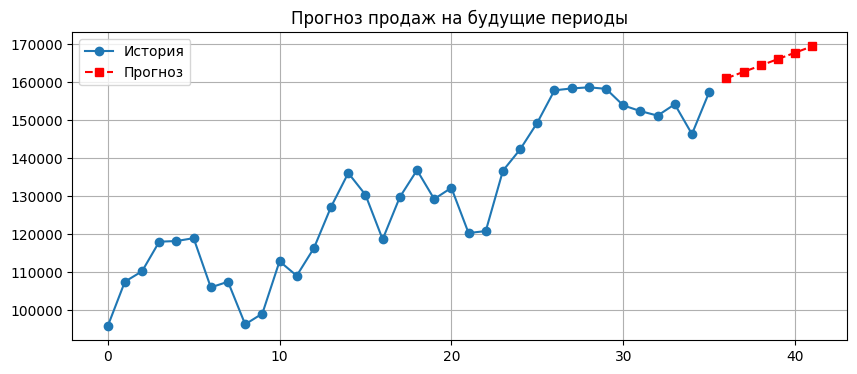

In [8]:
# 1. Задаем количество месяцев для прогноза (например, полгода)
future_months = 6
last_month_num = df['month_num'].max()

# 2. Создаем номера будущих месяцев
future_X = pd.DataFrame(np.arange(len(df), len(df) + future_months), columns=['month_num'])

# 3. Делаем прогноз через обученную модель lr_model
future_forecast = lr_model.predict(future_X)

# 4. Выводим результат в виде таблицы
print(f"--- Прогноз Линейной регрессии на {future_months} месяцев ---")
for i, value in enumerate(future_forecast, 1):
    print(f"Месяц {i} (2024 год): {value:.2f}")

# 5. Визуализация прогноза в консоли (простая проверка)
plt.figure(figsize=(10, 4))
plt.plot(range(len(df)), df['monthly_sales'], label='История', marker='o')
plt.plot(range(len(df), len(df) + future_months), future_forecast, label='Прогноз', color='red', linestyle='--', marker='s')
plt.title('Прогноз продаж на будущие периоды')
plt.legend()
plt.grid(True)
plt.show()